<a href="https://colab.research.google.com/github/Aaditya69Kumar/pandas-matplotlib-data-analysis/blob/main/Pandas_%26_Matplotlib_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Pandas?
If NumPy is about numbers, Pandas is about labeled data. It adds names to rows and columns so you can find data by meaning, not just position.
Key concepts:
1. Series
2. Dataframe
3. Handling NaNs: Using np.isnan() was the manual way; Pandas provides .fillna() for scalable cleaning.

# Pandas Cheat Sheet Link:- https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf

# 1. Series = A single column with labels

In [ ]:
import pandas as pd
import numpy as np
grades = pd.Series([85, 92, 78], index=['Alex', 'Maria', 'John'])
print(grades)

# 2. DataFrame = A whole spreadsheet

In [ ]:
# Like an entire Excel sheet
data = {
    'Name': ['Alex', 'Maria', 'John'],
    'Math': [85, 92, 78],
    'Science': [88, 94, 82],
    'Passed': [True, True, False]
}

df = pd.DataFrame(data)
print(df)

# REAL-WORLD DATASET: Student Performance Analysis
# To create dataset, run the code cell given below:

In [3]:
import pandas as pd
import numpy as np

# Create realistic student dataset
np.random.seed(42)
num_students = 50

student_data = {
    'Student_ID': [f'S{str(i).zfill(3)}' for i in range(1, num_students+1)],
    'Name': [f'Student_{i}' for i in range(1, num_students+1)],
    'Gender': np.random.choice(['Male', 'Female'], num_students),
    'Age': np.random.randint(18, 25, num_students),
    'Department': np.random.choice(['CS', 'ECE', 'ME', 'CE'], num_students, p=[0.4, 0.3, 0.2, 0.1]),
    'Study_Hours': np.random.uniform(10, 40, num_students).round(1),
    'Attendance': np.random.randint(60, 101, num_students),
    'Math_Score': np.random.normal(75, 15, num_students).clip(0, 100).astype(int),
    'Science_Score': np.random.normal(78, 12, num_students).clip(0, 100).astype(int),
    'Projects_Completed': np.random.randint(0, 6, num_students),
    'Has_Scholarship': np.random.choice([0, 1], num_students, p=[0.7, 0.3]),
    'Extracurricular': np.random.choice(['Yes', 'No'], num_students, p=[0.4, 0.6])
}

# Create DataFrame
students_df = pd.DataFrame(student_data)

# Add calculated columns
students_df['Total_Score'] = students_df['Math_Score'] + students_df['Science_Score']
students_df['Average_Score'] = students_df['Total_Score'] / 2
students_df['Performance'] = pd.cut(students_df['Average_Score'],
                                    bins=[0, 60, 75, 90, 100],
                                    labels=['Poor', 'Average', 'Good', 'Excellent'])

print("Dataset created successfully!")
print(f"Shape: {students_df.shape}")
print(f"Columns: {list(students_df.columns)}")
students_df.head()

Dataset created successfully!
Shape: (50, 15)
Columns: ['Student_ID', 'Name', 'Gender', 'Age', 'Department', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'Projects_Completed', 'Has_Scholarship', 'Extracurricular', 'Total_Score', 'Average_Score', 'Performance']


,Student_ID,Name,Gender,Age,Department,Study_Hours,Attendance,Math_Score,Science_Score,Projects_Completed,Has_Scholarship,Extracurricular,Total_Score,Average_Score,Performance
0,S001,Student_1,Male,24,ECE,24.3,61,78,80,4,0,No,158,79.0,Good
1,S002,Student_2,Female,23,CS,26.9,85,86,82,0,0,Yes,168,84.0,Good
2,S003,Student_3,Male,20,CE,30.9,91,56,67,1,1,No,123,61.5,Average
3,S004,Student_4,Male,21,ME,14.2,65,55,79,1,0,No,134,67.0,Average
4,S005,Student_5,Male,24,CS,28.1,91,82,78,0,0,No,160,80.0,Good


# Five Essential Pandas Skills

# Skill 1: Data Inspection & Exploration

In [4]:
# See your data
students_df.head()           # First 5 rows
students_df.tail(3)          # Last 3 rows
students_df.sample(5)        # Random 5 rows

# Understand your data
students_df.info()           # Data types & missing values
students_df.describe()       # Statistical summary (numerical columns)
students_df.describe(include='object')  # For categorical columns

# Shape and size
print(f"Rows: {students_df.shape[0]}, Columns: {students_df.shape[1]}")
print(f"Total cells: {students_df.size}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Student_ID          50 non-null     object  
 1   Name                50 non-null     object  
 2   Gender              50 non-null     object  
 3   Age                 50 non-null     int64   
 4   Department          50 non-null     object  
 5   Study_Hours         50 non-null     float64 
 6   Attendance          50 non-null     int64   
 7   Math_Score          50 non-null     int64   
 8   Science_Score       50 non-null     int64   
 9   Projects_Completed  50 non-null     int64   
 10  Has_Scholarship     50 non-null     int64   
 11  Extracurricular     50 non-null     object  
 12  Total_Score         50 non-null     int64   
 13  Average_Score       50 non-null     float64 
 14  Performance         50 non-null     category
dtypes: category(1), float64(2), int64(7), obje

# Skill 2: Data Selection

In [5]:
# Single column (returns Series)
students_df['Name']
students_df.Name  # Same as above but only works if column name has no spaces

# Multiple columns (returns DataFrame)
students_df[['Name', 'Math_Score', 'Department']]

# By position (iloc = integer location)
students_df.iloc[0]           # First row (all columns)
students_df.iloc[0:5, 1:4]    # Rows 0-4, columns 1-3

# By label (loc = label location)
# If the index is already 'Student_ID' from a previous run, reset it to default integer index for this example
if students_df.index.name == 'Student_ID':
    students_df.reset_index(inplace=True)

print(f"Name at integer index 0: {students_df.loc[0, 'Name']}") # Row 0, column 'Name' (Works when index is default integer index)

students_df.set_index('Student_ID', inplace=True)  # Set ID as index
print(f"Name for 'S001' after setting Student_ID as index: {students_df.loc['S001', 'Name']}")  # Now access by Student_ID

Name at integer index 0: Student_1
Name for 'S001' after setting Student_ID as index: Student_1


# Skill 3: Filtering Data

In [6]:
# Single condition
math_above_85 = students_df[students_df['Math_Score'] > 85]
failed_students = students_df[students_df['Average_Score'] < 60]

# Multiple conditions
top_performers = students_df[(students_df['Math_Score'] > 90) &
                             (students_df['Science_Score'] > 90)]

cs_students = students_df[(students_df['Department'] == 'CS') |
                          (students_df['Department'] == 'ECE')]

# Inverse filtering (NOT condition)
not_cs = students_df[students_df['Department'] != 'CS']

# Query method (SQL-like syntax)
query_result = students_df.query('Math_Score > 80 and Study_Hours > 20')

# Skill 4: Data Cleaning

In [7]:
# Let's add some missing values to simulate real data
students_df_messy = students_df.copy()
students_df_messy.iloc[[0, 5, 10], students_df_messy.columns.get_loc('Math_Score')] = np.nan
students_df_messy.iloc[[2, 8], students_df_messy.columns.get_loc('Department')] = None
students_df_messy.iloc[15, students_df_messy.columns.get_loc('Age')] = 200  # Outlier!

#  1 Check for missing values
print("Missing values per column:")
print(students_df_messy.isnull().sum())

# 2 Fill missing values
students_df_clean = students_df_messy.copy()
students_df_clean['Math_Score'] = students_df_clean['Math_Score'].fillna(students_df_clean['Math_Score'].mean())
students_df_clean['Department'] = students_df_clean['Department'].fillna('Unknown')

# 3️ Remove outliers
students_df_clean = students_df_clean[students_df_clean['Age'] < 100]

# 4  Drop duplicates
students_df_clean = students_df_clean.drop_duplicates()

print("Data cleaning complete!")

Missing values per column:
Name                  0
Gender                0
Age                   0
Department            2
Study_Hours           0
Attendance            0
Math_Score            3
Science_Score         0
Projects_Completed    0
Has_Scholarship       0
Extracurricular       0
Total_Score           0
Average_Score         0
Performance           0
dtype: int64
Data cleaning complete!


# Skill 5: Grouping & Aggregation - Find Patterns

In [8]:
# Group by Department and calculate statistics
dept_stats = students_df.groupby('Department').agg({
    'Math_Score': ['mean', 'min', 'max', 'count'],
    'Science_Score': 'mean',
    'Average_Score': 'median'
}).round(2)

print("Department-wise Statistics:")
print(dept_stats)

# Group by multiple columns
gender_dept_stats = students_df.groupby(['Gender', 'Department'])['Average_Score'].mean().unstack()
print("\nGender × Department Average Scores:")
print(gender_dept_stats)

# Value counts (for categorical data)
print("\nDepartment Distribution:")
print(students_df['Department'].value_counts())

print("\nPerformance Distribution:")
print(students_df['Performance'].value_counts(normalize=True).round(2) * 100)

Department-wise Statistics:
           Math_Score                Science_Score Average_Score
                 mean min  max count          mean        median
Department                                                      
CE              75.33  56  100     6         81.83          80.0
CS              75.84  57   89    19         79.16          76.5
ECE             78.13  62  100    15         73.80          75.5
ME              71.20  52  100    10         82.50          74.5

Gender × Department Average Scores:
Department      CE         CS        ECE         ME
Gender                                             
Female      80.000  75.846154  73.583333  75.666667
Male        77.875  81.083333  77.555556  78.625000

Department Distribution:
Department
CS     19
ECE    15
ME     10
CE      6
Name: count, dtype: int64

Performance Distribution:
Performance
Good         52.0
Average      38.0
Excellent     8.0
Poor          2.0
Name: proportion, dtype: float64


# Link for Study:- https://pandas.pydata.org/docs/user_guide/index.html

# Matplotlib - The Art of Data Visualization
Matplotlib Cheat sheet Link: https://matplotlib.org/cheatsheets/cheatsheets.pdf

In [9]:
import matplotlib.pyplot as plt

# (shows plots in notebook)
%matplotlib inline

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')

# Plot 1: Histogram

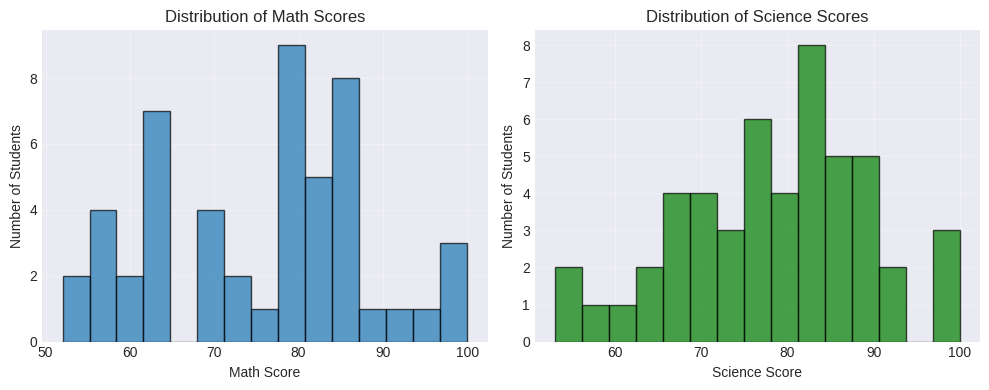

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(students_df['Math_Score'], bins=15, edgecolor='black', alpha=0.7)
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(students_df['Science_Score'], bins=15, edgecolor='black',
         alpha=0.7, color='green')
plt.title('Distribution of Science Scores')
plt.xlabel('Science Score')
plt.ylabel('Number of Students')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Scatter Plot

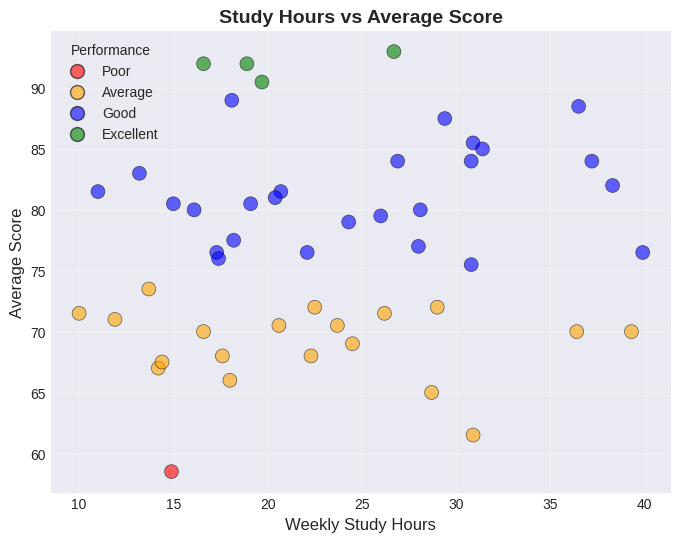

In [11]:
plt.figure(figsize=(8, 6))

# Color by Performance
colors = {'Poor': 'red', 'Average': 'orange', 'Good': 'blue', 'Excellent': 'green'}
color_list = [colors[p] for p in students_df['Performance']]

plt.scatter(students_df['Study_Hours'], students_df['Average_Score'],
            c=color_list, alpha=0.6, s=100, edgecolor='black', linewidth=0.5)

plt.title('Study Hours vs Average Score', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Study Hours', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, alpha=0.3)

# Add legend
for performance, color in colors.items():
    plt.scatter([], [], c=color, alpha=0.6, s=100, label=performance, edgecolor='black')
plt.legend(title='Performance')

plt.show()

# Plot 3: Bar Plot

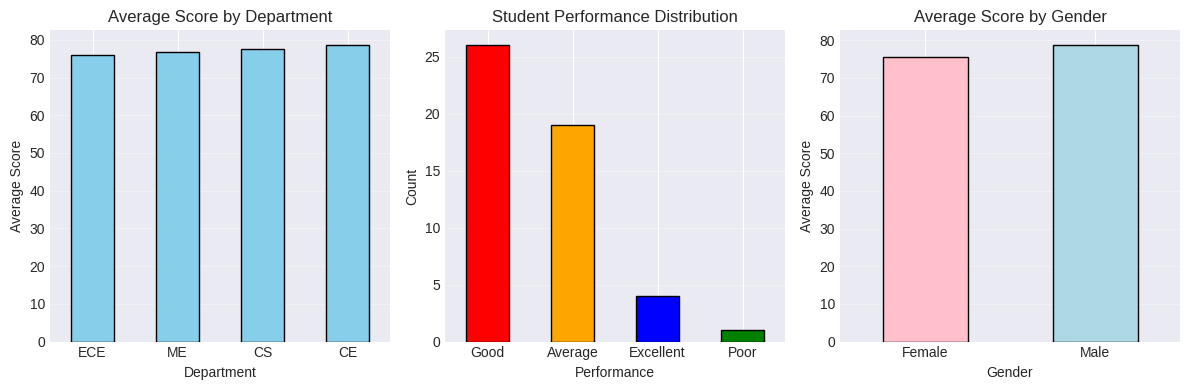

In [12]:
plt.figure(figsize=(12, 4))

# Plot 1: Department-wise average scores
plt.subplot(1, 3, 1)
dept_avg = students_df.groupby('Department')['Average_Score'].mean().sort_values()
dept_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Score by Department')
plt.xlabel('Department')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Plot 2: Performance distribution
plt.subplot(1, 3, 2)
performance_counts = students_df['Performance'].value_counts()
performance_counts.plot(kind='bar', color=['red', 'orange', 'blue', 'green'],
                       edgecolor='black')
plt.title('Student Performance Distribution')
plt.xlabel('Performance')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Plot 3: Gender comparison
plt.subplot(1, 3, 3)
gender_avg = students_df.groupby('Gender')['Average_Score'].mean()
gender_avg.plot(kind='bar', color=['pink', 'lightblue'], edgecolor='black')
plt.title('Average Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 4: Box Plot

/tmp/ipykernel_5354/2656310443.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=departments, patch_artist=True)


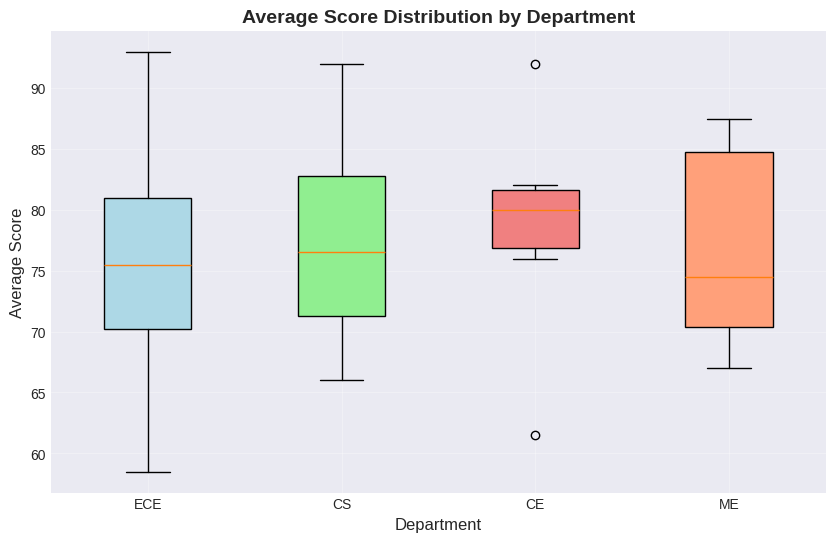

In [13]:
plt.figure(figsize=(10, 6))

# Create data for box plot
data_to_plot = []
departments = students_df['Department'].unique()

for dept in departments:
    data_to_plot.append(students_df[students_df['Department'] == dept]['Average_Score'].values)

# Create box plot
box = plt.boxplot(data_to_plot, labels=departments, patch_artist=True)

# Customize colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Average Score Distribution by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Plot 5: Pie Chart

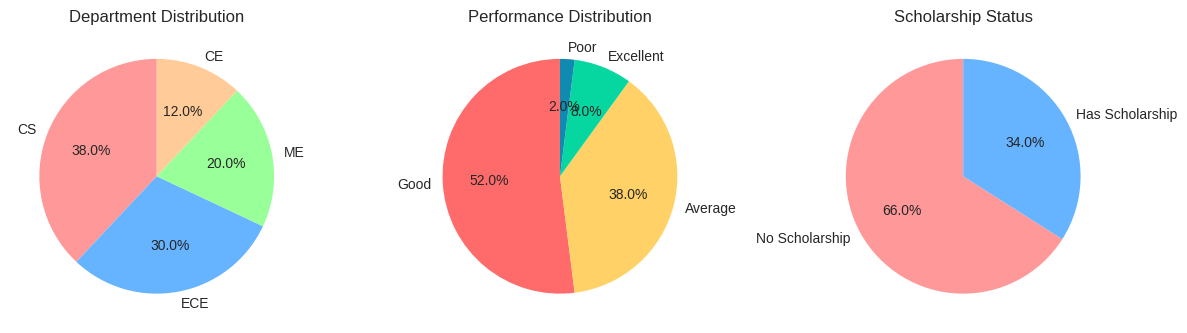

In [14]:
plt.figure(figsize=(12, 4))

# Plot 1: Department distribution
plt.subplot(1, 3, 1)
dept_counts = students_df['Department'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Department Distribution')

# Plot 2: Performance distribution
plt.subplot(1, 3, 2)
perf_counts = students_df['Performance'].value_counts()
colors = ['#ff6b6b', '#ffd166', '#06d6a0', '#118ab2']
plt.pie(perf_counts.values, labels=perf_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Performance Distribution')

# Plot 3: Scholarship status
plt.subplot(1, 3, 3)
scholarship_counts = students_df['Has_Scholarship'].value_counts()
labels = ['No Scholarship', 'Has Scholarship']
colors = ['#ff9999', '#66b3ff']
plt.pie(scholarship_counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Scholarship Status')

plt.tight_layout()
plt.show()

# Link for Study:- https://matplotlib.org/2.0.2/users/pyplot_tutorial.html